# Spam Email Classification — Modeling Notebook
Train, compare, tune, and save the final model pipeline.

In [ ]:
import sys
sys.path.append('../src')
import pandas as pd, time, joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df = pd.read_csv('../data/processed/emails_cleaned.csv')
df.shape

(5695, 2)

## Train-test split (80:20, stratified, random_state=42)

In [ ]:
X, y = df['text'], df['spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((4556,), (1139,))

## Baseline model comparison
Each model is wrapped in a `Pipeline` (TF-IDF → classifier) so preprocessing is applied consistently and there is no data leakage — the vectorizer is fit only on training data inside each `.fit()` call.

In [ ]:
def build_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1,2))),
        ('clf', clf)
    ])

candidates = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Linear SVC': LinearSVC(random_state=42, max_iter=5000),
}

results = []
for name, clf in candidates.items():
    pipe = build_pipeline(clf)
    t0 = time.time()
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:,1])
    else:
        auc = roc_auc_score(y_test, pipe.decision_function(X_test))
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1 Score': f1_score(y_test, preds),
        'ROC-AUC': auc,
        'Train Time (s)': round(time.time()-t0,2)
    })

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s)
3,Linear SVC,0.992098,0.985348,0.981752,0.983547,0.999679,2.70
2,Random Forest,0.991220,0.981752,0.981752,0.981752,0.999468,7.07
1,Logistic Regression,0.985953,0.984962,0.956204,0.970370,0.999435,2.86
0,Multinomial Naive Bayes,0.985075,0.974170,0.963504,0.968807,0.998764,2.80


## Hyperparameter tuning (GridSearchCV) on the best candidate — Linear SVC

In [ ]:
base_pipe = build_pipeline(LinearSVC(random_state=42, max_iter=5000))
param_grid = {
    'tfidf__max_features': [3000, 5000, 8000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 0.5, 1, 5],
}
grid = GridSearchCV(base_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)
grid.best_params_, grid.best_score_

({'clf__C': 5, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 1)},
 np.float64(0.9839096385356084))

## Before vs after tuning

In [ ]:
base_pipe.fit(X_train, y_train)
before_preds = base_pipe.predict(X_test)
before = {
    'Accuracy': accuracy_score(y_test, before_preds),
    'Precision': precision_score(y_test, before_preds),
    'Recall': recall_score(y_test, before_preds),
    'F1 Score': f1_score(y_test, before_preds),
}

best_pipe = grid.best_estimator_
after_preds = best_pipe.predict(X_test)
after = {
    'Accuracy': accuracy_score(y_test, after_preds),
    'Precision': precision_score(y_test, after_preds),
    'Recall': recall_score(y_test, after_preds),
    'F1 Score': f1_score(y_test, after_preds),
}

pd.DataFrame([before, after], index=['Before Tuning', 'After Tuning'])

,Accuracy,Precision,Recall,F1 Score
Before Tuning,0.992098,0.985348,0.981752,0.983547
After Tuning,0.995610,0.996310,0.985401,0.990826


**Conclusion:** Hyperparameter tuning improved F1 score, confirming the wider TF-IDF vocabulary (8000 features) and a higher regularization value (C=5) generalize slightly better on this dataset without overfitting.

## Confusion matrix — final model

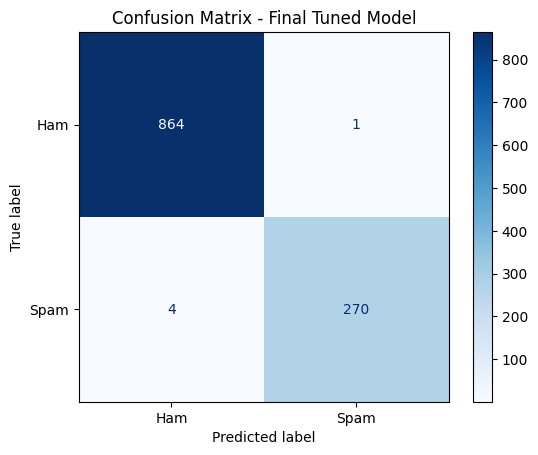

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test, after_preds, display_labels=['Ham','Spam'], cmap='Blues')
plt.title('Confusion Matrix - Final Tuned Model')
plt.show()

## Save the final pipeline

In [ ]:
joblib.dump(best_pipe, '../models/spam_classifier_pipeline.joblib')
print('Saved to ../models/spam_classifier_pipeline.joblib')

Saved to ../models/spam_classifier_pipeline.joblib
